<a href="https://colab.research.google.com/github/saramendesoliveiralima/cursodeautomacaodetestesweb/blob/master/SARA_LIMA_Atividade_Perceptron_e_MLP_com_scripts_programados_com_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Atividade - Perceptron e MLP com scripts programados com PyTorch**

**Observação:** Os trabalhos serão avaliados apenas se implementados por PyTorch.

*   **Nome**: Sara Mendes Oliveira Lima
*   **Matrícula**: 261112448

---

# **Diagnóstico de Diabetes com Redes Neurais**

Nesta atividade, vamos trabalhar com um problema aplicado de **classificação binária**: prever se uma pessoa possui ou não diabetes com base em um conjunto de variáveis clínicas.

[Pima Indians Diabetes Database](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)

---

## **Contexto**

- O dataset utilizado é o **Pima Indians Diabetes Dataset**, coletado originalmente pelo Instituto Nacional de Diabetes e Doenças Digestivas e Renais dos Estados Unidos.
- Ele contém registros de mulheres com pelo menos 21 anos de idade da população Pima, um grupo étnico nativo norte-americano com alta incidência de diabetes tipo 2.

## **Objetivo**

O objetivo é treinar uma MLP para prever a presença de diabetes a partir de atributos fisiológicos e laboratoriais.

## **Variáveis de entrada**

Cada observação contém os seguintes atributos:

1. **Pregnancies**, number of times pregnant: Variável discreta.
2. **Glucose**, plasma glucose concentration after 2 hours in an oral glucose tolerance test: Variável contínua.
3. **BloodPressure**, diastolic blood pressure, in mm Hg: Variável contínua.
4. **SkinThickness**, triceps skin fold thickness, in mm: Variável contínua.
5. **Insulin**, 2-hour serum insulin, in μU/mL: Variável contínua.
6. **BMI**, body mass index, weight in kg/(height in m)²: Variável contínua.
7. **DiabetesPedigreeFunction**, family history function: Variável contínua.
8. **Age**, in years: : Variável discreta.

## **Variáveis de saída (Target)**

- **Outcome = 1**: Diabetic
- **Outcome = 0**: Non-diabetic


# **Exercício 1 - Preparação dos dados**

1. Apresente um resumo estatístico básico e visualizações simples, como correlação entre variáveis e histogramas procurando inconsistências que podem afetar a construção do modelo.
2. Faça a divisão dos dados:
  - 70% para treino
  - 15% para validação
  - 15% para teste

Use como exemplo a aula colab do dia 21/05/2025.
```python
import pandas as pd

# URL do dataset
url = "https://raw.githubusercontent.com/pcbrom/perceptron-mlp-cnn/refs/heads/main/data/diabetes.csv"

# Carregar o dataset
df = pd.read_csv(url)
```



**Apresente um resumo estatístico básico e visualizações simples, como correlação entre variáveis e histogramas procurando inconsistências que podem afetar a construção do modelo.**

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

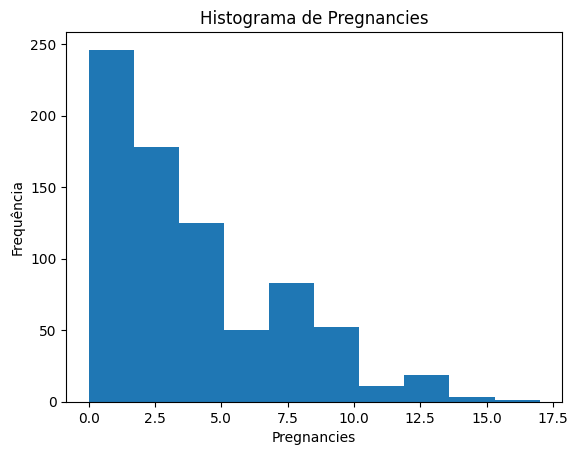

Glucose
99     17
100    17
111    14
125    14
129    14
       ..
56      1
169     1
149     1
65      1
190     1
Name: count, Length: 136, dtype: int64


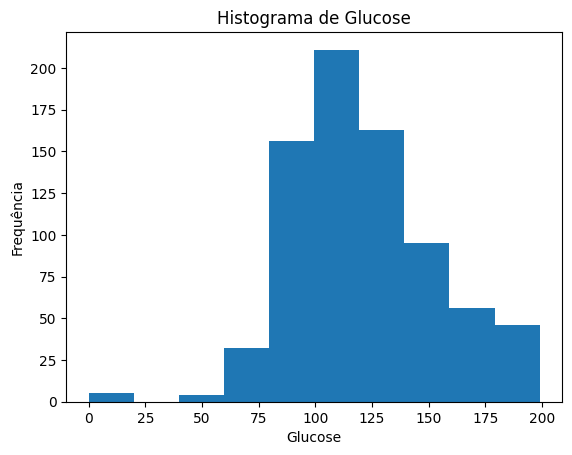

BloodPressure
70     57
74     52
78     45
68     45
72     44
64     43
80     40
76     39
60     37
0      35
62     34
66     30
82     30
88     25
84     23
90     22
86     21
58     21
50     13
56     12
54     11
52     11
92      8
75      8
65      7
85      6
94      6
48      5
44      4
96      4
110     3
106     3
100     3
98      3
30      2
46      2
55      2
104     2
108     2
40      1
122     1
95      1
102     1
61      1
24      1
38      1
114     1
Name: count, dtype: int64


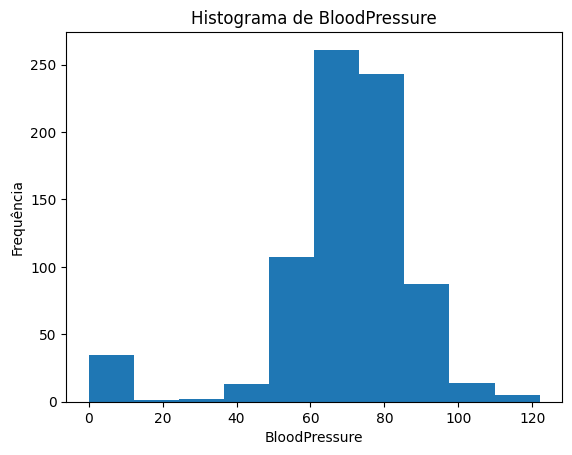

SkinThickness
0     227
32     31
30     27
27     23
23     22
18     20
33     20
28     20
31     19
39     18
19     18
29     17
25     16
40     16
22     16
37     16
26     16
41     15
35     15
36     14
15     14
17     14
20     13
24     12
42     11
13     11
21     10
46      8
34      8
12      7
38      7
16      6
11      6
45      6
14      6
43      6
44      5
10      5
47      4
48      4
49      3
50      3
54      2
8       2
52      2
7       2
60      1
51      1
56      1
63      1
99      1
Name: count, dtype: int64


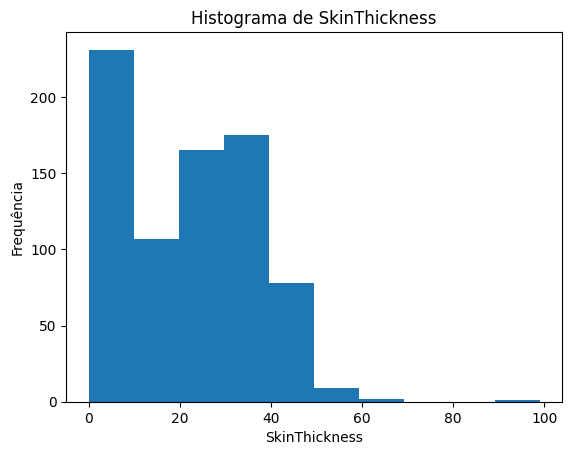

Insulin
0      374
105     11
130      9
140      9
120      8
      ... 
178      1
127      1
510      1
16       1
112      1
Name: count, Length: 186, dtype: int64


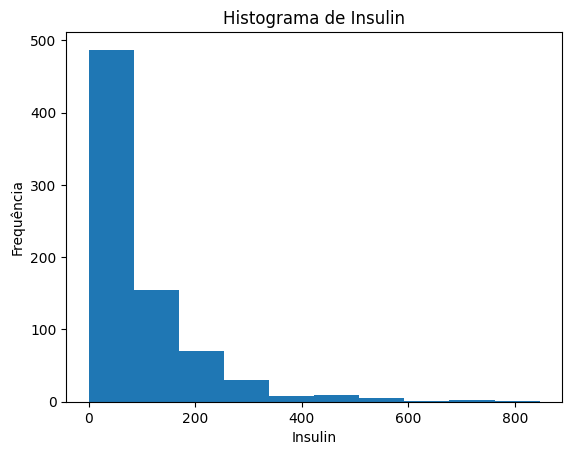

BMI
32.0    13
31.6    12
31.2    12
0.0     11
32.4    10
        ..
49.6     1
24.1     1
41.2     1
49.3     1
46.3     1
Name: count, Length: 248, dtype: int64


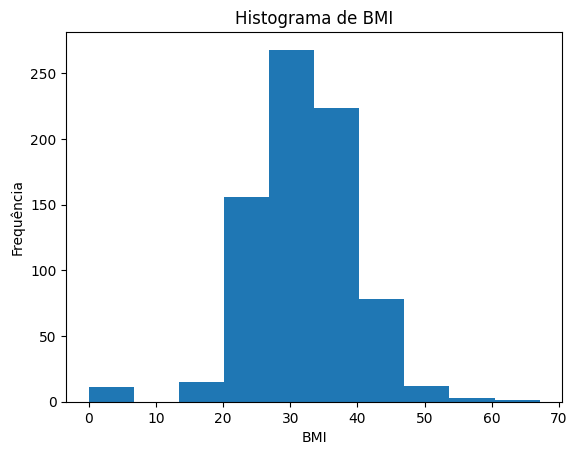

DiabetesPedigreeFunction
0.258    6
0.254    6
0.207    5
0.261    5
0.259    5
        ..
0.565    1
0.118    1
0.177    1
0.176    1
0.295    1
Name: count, Length: 517, dtype: int64


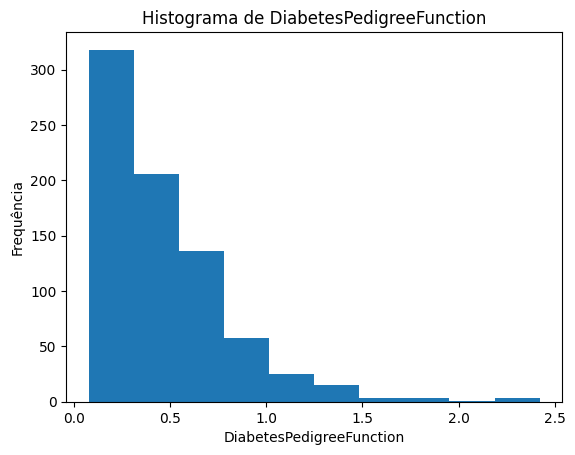

Age
22    72
21    63
25    48
24    46
23    38
28    35
26    33
27    32
29    29
31    24
41    22
30    21
37    19
42    18
33    17
36    16
38    16
32    16
45    15
34    14
46    13
40    13
43    13
39    12
35    10
44     8
50     8
51     8
52     8
58     7
54     6
47     6
49     5
60     5
53     5
57     5
48     5
63     4
66     4
55     4
62     4
59     3
56     3
65     3
67     3
61     2
69     2
72     1
81     1
64     1
70     1
68     1
Name: count, dtype: int64


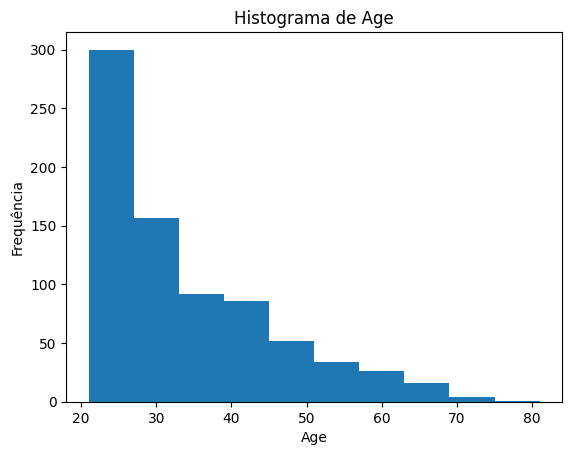

Outcome
0    500
1    268
Name: count, dtype: int64


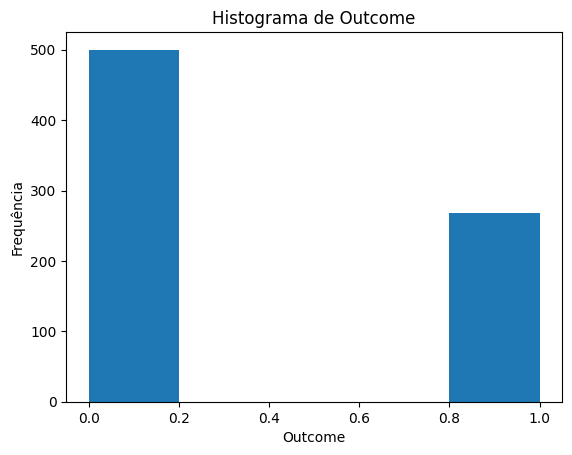

                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.129459       0.141282      -0.081672   
Glucose                      0.129459  1.000000       0.152590       0.057328   
BloodPressure                0.141282  0.152590       1.000000       0.207371   
SkinThickness               -0.081672  0.057328       0.207371       1.000000   
Insulin                     -0.073535  0.331357       0.088933       0.436783   
BMI                          0.017683  0.221071       0.281805       0.392573   
DiabetesPedigreeFunction    -0.033523  0.137337       0.041265       0.183928   
Age                          0.544341  0.263514       0.239528      -0.113970   
Outcome                      0.221898  0.466581       0.065068       0.074752   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies              -0.073535  0.017683                 -0.033523   
Glucose                   0.331357  0.221

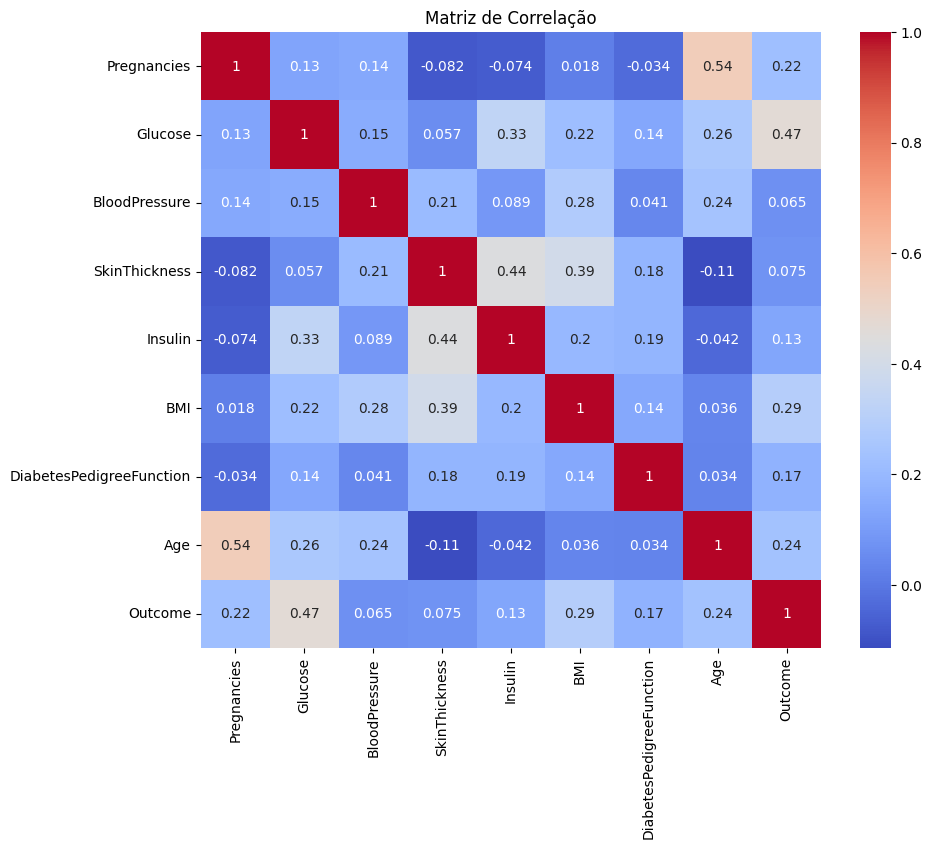

Empty DataFrame
Columns: [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age, Outcome]
Index: []
Empty DataFrame
Columns: [Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age, Outcome]
Index: []
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
75             1        0             48             20        0  24.7   
182            1        0             74             20       23  27.7   
342            1        0             68             35        0  32.0   
349            5        0             80             32        0  41.0   
502            6        0             68             41        0  39.0   

     DiabetesPedigreeFunction  Age  Outcome  
75                      0.140   22        0  
182                     0.299   21        0  
342                     0.389   22        0  
349                     0.346   37        1  
502                     0.727   41       

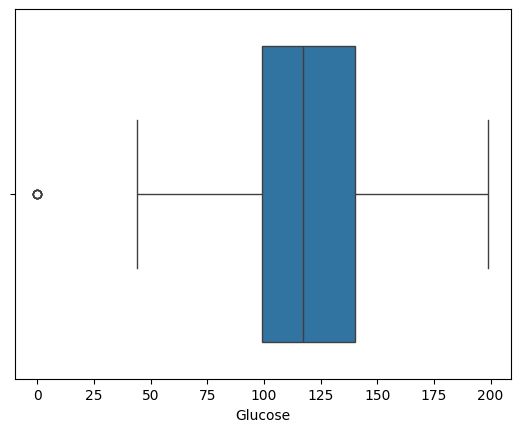

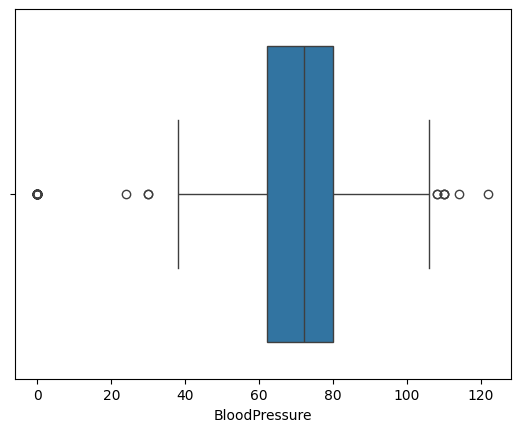

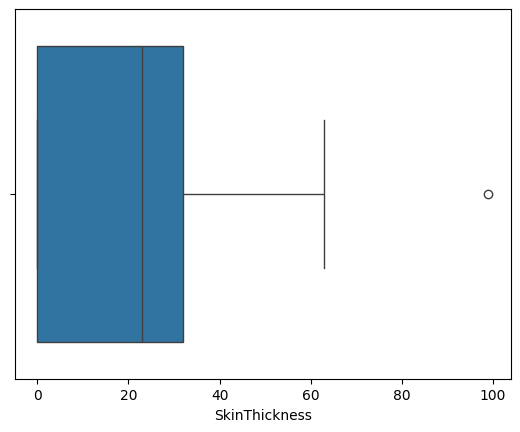

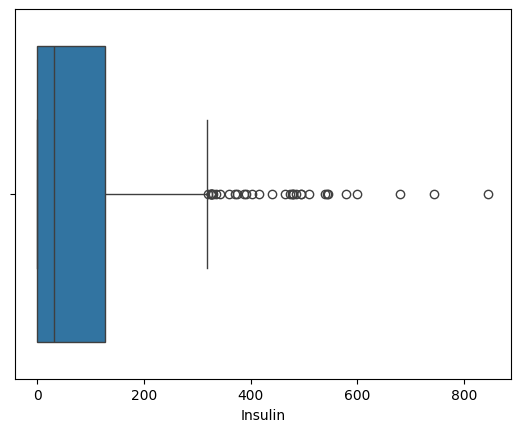

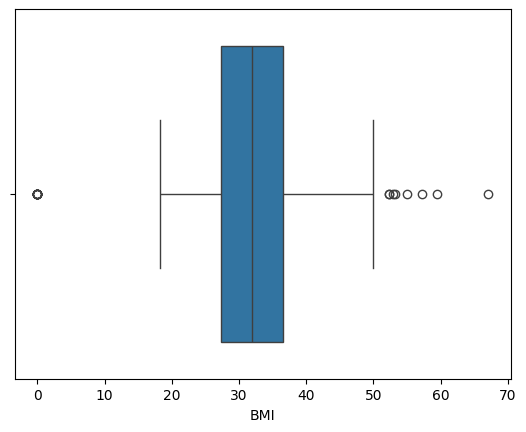

Pregnancies: 4 outliers
Glucose: 5 outliers
BloodPressure: 45 outliers
SkinThickness: 1 outliers
Insulin: 34 outliers
BMI: 19 outliers
DiabetesPedigreeFunction: 29 outliers
Age: 9 outliers


In [29]:
## Importando as bibliotecas necessárias:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix

## Carregando o DataSet:

url = "https://raw.githubusercontent.com/pcbrom/perceptron-mlp-cnn/refs/heads/main/data/diabetes.csv"

df = pd.read_csv(url)


## Resumo estatístico básico das variáveis:

print(df.describe())


## Verificando se existem valores ausentes:

print(df.isnull().sum())


## Verificando a distribuição das classes:

## Pregnancies

print(df['Pregnancies'].value_counts())
plt.hist(df['Pregnancies'], bins=10)
plt.title('Histograma de Pregnancies')
plt.xlabel('Pregnancies')
plt.ylabel('Frequência')
plt.show()


## Glucose

print(df['Glucose'].value_counts())
plt.hist(df['Glucose'], bins=10)
plt.title('Histograma de Glucose')
plt.xlabel('Glucose')
plt.ylabel('Frequência')
plt.show()


## BloodPressure

print(df['BloodPressure'].value_counts())
plt.hist(df['BloodPressure'], bins=10)
plt.title('Histograma de BloodPressure')
plt.xlabel('BloodPressure')
plt.ylabel('Frequência')
plt.show()


## SkinThickness

print(df['SkinThickness'].value_counts())
plt.hist(df['SkinThickness'], bins=10)
plt.title('Histograma de SkinThickness')
plt.xlabel('SkinThickness')
plt.ylabel('Frequência')
plt.show()


## Insulin

print(df['Insulin'].value_counts())
plt.hist(df['Insulin'], bins=10)
plt.title('Histograma de Insulin')
plt.xlabel('Insulin')
plt.ylabel('Frequência')
plt.show()


## BMI

print(df['BMI'].value_counts())
plt.hist(df['BMI'], bins=10)
plt.title('Histograma de BMI')
plt.xlabel('BMI')
plt.ylabel('Frequência')
plt.show()


## DiabetesPedigreeFunction

print(df['DiabetesPedigreeFunction'].value_counts())
plt.hist(df['DiabetesPedigreeFunction'], bins=10)
plt.title('Histograma de DiabetesPedigreeFunction')
plt.xlabel('DiabetesPedigreeFunction')
plt.ylabel('Frequência')
plt.show()


## Age

print(df['Age'].value_counts())
plt.hist(df['Age'], bins=10)
plt.title('Histograma de Age')
plt.xlabel('Age')
plt.ylabel('Frequência')
plt.show()


## Outcome

print(df['Outcome'].value_counts())
plt.hist(df['Outcome'], bins=5)
plt.title('Histograma de Outcome')
plt.xlabel('Outcome')
plt.ylabel('Frequência')
plt.show()


## Correlação entre as variáveis:

corr = df.corr(numeric_only=True)
print(corr)
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Matriz de Correlação")
plt.show()


## Buscando inconsistências:

## Pregnancies

print(df[df['Pregnancies'] < 0])
print(df[df['Pregnancies'] > 20])


## Glucose

print(df[df['Glucose'] <= 0])


## Blood Pressure

print(df[df['BloodPressure'] == 0])
print(df[(df['BloodPressure'] > 0) & (df['BloodPressure'] <= 20)])
print(df[(df['BloodPressure'] > 0) & (df['BloodPressure'] <= 20)])


## Skin Thickness

print(df[df['SkinThickness'] == 0])
print(df[df['SkinThickness'] > 80])


## Insulin

print(df[df['Insulin'] == 0])
print(df[df['Insulin'] > 1000])


## BMI

print(df[df['BMI'] == 0])
print(df[(df['BMI'] > 0) & (df['BMI'] <= 5)])
print(df[df['BMI'] > 80])


## Diabetes Pedigree Function:

print(df[df['DiabetesPedigreeFunction'] < 0])
print(df[df['DiabetesPedigreeFunction'] > 5])


## Age:

print(df[df['Age'] <= 0])
print(df[df['Age'] > 150])


## Detectar variáveis onde zero costuma significar "missing value":

cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols:
    print(col)
    print(df[df[col] == 0].shape[0])


## Substituir zeros por mediana:

cols = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

for col in cols:
    df[col] = df[col].fillna(df[col].median())


## Detectar ouliers com bloxplot:

## Glucose

sns.boxplot(x=df['Glucose'])
plt.show()


## BloodPressure

sns.boxplot(x=df['BloodPressure'])
plt.show()


## SkinThickness

sns.boxplot(x=df['SkinThickness'])
plt.show()


## Insulin

sns.boxplot(x=df['Insulin'])
plt.show()


## BMI

sns.boxplot(x=df['BMI'])
plt.show()


numericas = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
]

for coluna in numericas:

    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    n_outliers = df[
        (df[coluna] < limite_inferior) |
        (df[coluna] > limite_superior)
    ].shape[0]

    print(f"{coluna}: {n_outliers} outliers")



**Faça a divisão dos dados:**

*   70% para treino
*   15% para validação
*   15% para teste


In [30]:
## Separar atributos e saída:

X = df.drop('Outcome', axis=1)
y = df['Outcome']


## Primeira divisão:
## 70% treino
## 30% temporário

from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

## Segunda divisão:
## 15% validação
## 15% teste

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

## Conferindo tamanhos:

print("Treino:", X_train.shape)
print("Validação:", X_val.shape)
print("Teste:", X_test.shape)


Treino: (537, 8)
Validação: (115, 8)
Teste: (116, 8)


# **Exercício 2 - Construção MLP**

1. Proponha uma arquiterura de MLP, defina os hiperparâmetros, otimizador, função de perda.
2. Faça o treinamento da rede e apresente:
  - Acurácia no conjunto de teste.
  - Matriz de confusão.
  - Relatório de classificação.

Use como exemplo a aula colab.

```python
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
# --- Acurácia
acc_test = accuracy_score(y_true_test, y_pred_test)
print(f"Acurácia no conjunto de teste: {acc_test:.4f}")

# --- Matriz de confusão
cm = confusion_matrix(y_true_test, y_pred_test)
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão (Teste)')
plt.xlabel('Classe Predita')
plt.ylabel('Classe Real')
plt.tight_layout()
plt.show()

# --- Relatório de classificação
print("\nRelatório de Classificação:")
print(classification_report(y_true_test, y_pred_test, digits=4, zero_division=1))
```

**Proposta Arquitetura 1:**

Entradas -> Camada Oculta 1 -> Camada Oculta 2 -> Camada de Saída


**Aplicação no contexto atual:**

8 Entradas
(Pregnancies, Glucose, BloodPressure, SkinThickness,
Insulin, BMI, DiabetesPedigreeFunction, Age) -> 16 neurônios (ReLU) ->
8 neurônios (ReLU) -> 1 neurônio (Sigmoid) -> Diabetes = Sim ou Não



Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6518 - loss: 24.8887 - val_accuracy: 0.6522 - val_loss: 18.2556
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6518 - loss: 16.8230 - val_accuracy: 0.6522 - val_loss: 10.6347
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6145 - loss: 9.2055 - val_accuracy: 0.5478 - val_loss: 4.3510
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4488 - loss: 4.7549 - val_accuracy: 0.5130 - val_loss: 3.0504
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4544 - loss: 3.1225 - val_accuracy: 0.5043 - val_loss: 2.6979
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4749 - loss: 2.7732 - val_accuracy: 0.4348 - val_loss: 2.6645
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4730 - loss: 2.5119 - val_accuracy: 0.4522 - val_loss: 2.3632
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4749 - loss: 2.3030 - val_accuracy: 0.4696 - val_loss

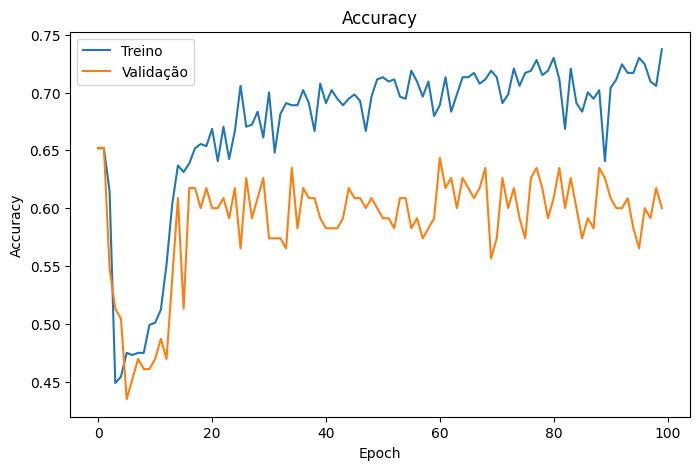

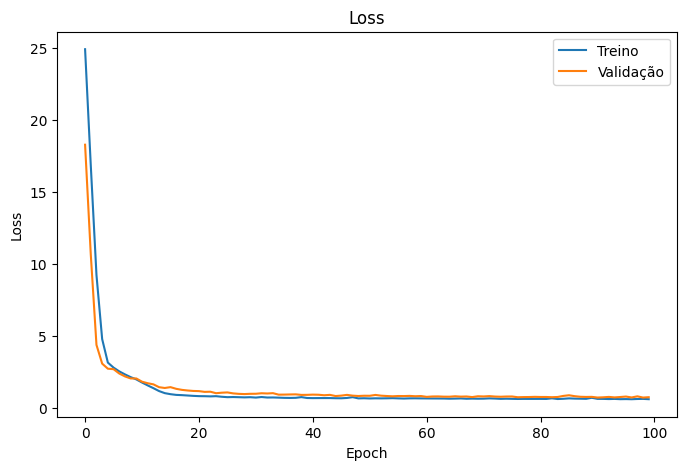

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7300 - loss: 0.5878 - val_accuracy: 0.6435 - val_loss: 0.6609
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7169 - loss: 0.5867 - val_accuracy: 0.6261 - val_loss: 0.7277
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7188 - loss: 0.5760 - val_accuracy: 0.6087 - val_loss: 0.6897
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7188 - loss: 0.5860 - val_accuracy: 0.6348 - val_loss: 0.6830
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7207 - loss: 0.5809 - val_accuracy: 0.6174 - val_loss: 0.6940
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7505 - loss: 0.5671 - val_accuracy: 0.6261 - val_loss: 0.6678
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7281 - loss: 0.5680 - val_accuracy: 0.6174 - val_loss: 0.6768
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7467 - loss: 0.5655 - val_accuracy: 0.6174 - v

In [31]:
## Criando a arquitetura:

## 8 entradas -> 16 neurônios (ReLU) -> 8 neurônios (ReLU) -> 1 neurônio (Sigmoid)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(16, activation='relu', input_shape=(8,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])


## Configurando otimizador e função de perda:
## Otimizador: Adam
## Learning Rate: 0.001
## Função de perda: Binary Crossentropy


from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Treinando a Rede:

## Hiperparâmetros:
## epochs = 100
## batch_size = 32


history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

## Avaliando no Conjunto de Teste:

loss, accuracy = model.evaluate(X_test, y_test)

print(f'Loss: {loss:.4f}')
print(f'Accuracy: {accuracy:.4f}')

## Fazendo previsões:

y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)


## Matriz de Confusão:

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)


## Relatório de Classificação:

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))



## Plotando curvas de treinamento:

## Acucária:

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Treino', 'Validação'])

plt.show()


## Função de Perda:

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Treino', 'Validação'])

plt.show()

## Adicionando Early Stopping - para evitar overfitting.

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


## Treinamento:

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)






**Proposta Arquitetura 2:**

Entradas -> Camada Oculta 1 -> Camada Oculta 2 -> Camada de Saída


**Aplicação no contexto atual:**

8 Entradas
(Pregnancies, Glucose, BloodPressure, SkinThickness,
Insulin, BMI, DiabetesPedigreeFunction, Age) -> 32 neurônios (ReLU) ->
16 neurônios (ReLU) -> 1 neurônio (Sigmoid) -> Diabetes = Sim ou Não *texto em itálico*



Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5661 - loss: 2.3759 - val_accuracy: 0.5913 - val_loss: 1.1748
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5642 - loss: 1.5646 - val_accuracy: 0.6174 - val_loss: 1.0923
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6071 - loss: 1.1775 - val_accuracy: 0.5739 - val_loss: 0.9975
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6182 - loss: 0.9955 - val_accuracy: 0.5130 - val_loss: 0.9682
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6462 - loss: 0.8947 - val_accuracy: 0.5739 - val_loss: 0.8858
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6182 - loss: 0.8619 - val_accuracy: 0.5130 - val_loss: 0.8960
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6425 - loss: 0.8123 - val_accuracy: 0.5913 - val_loss: 0.8072
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6574 - loss: 0.7949 - val_accuracy: 0.6087 - val_loss: 0.

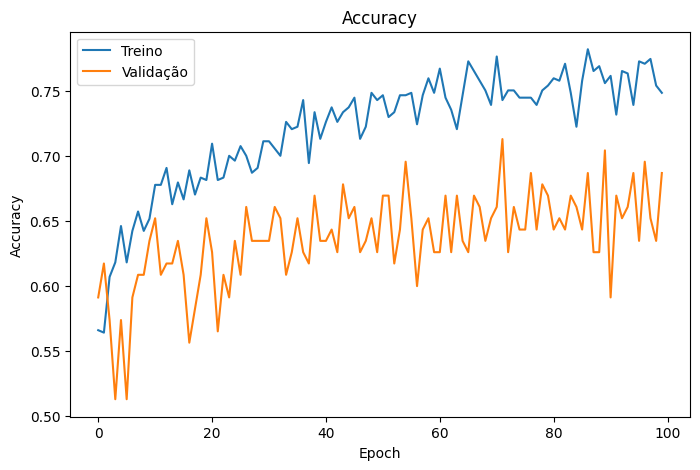

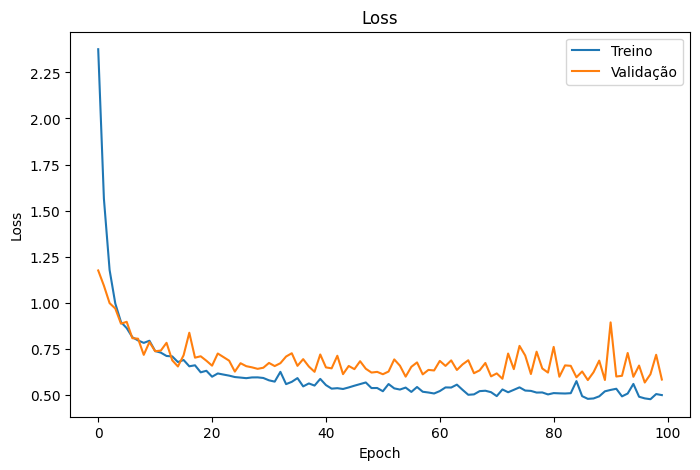

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7877 - loss: 0.4759 - val_accuracy: 0.6348 - val_loss: 0.6539
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7709 - loss: 0.4727 - val_accuracy: 0.6870 - val_loss: 0.5943
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7672 - loss: 0.4893 - val_accuracy: 0.6522 - val_loss: 0.6119
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7747 - loss: 0.4765 - val_accuracy: 0.6348 - val_loss: 0.6258
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7616 - loss: 0.4871 - val_accuracy: 0.6261 - val_loss: 0.6407
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7765 - loss: 0.4793 - val_accuracy: 0.6609 - val_loss: 0.6822
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7635 - loss: 0.4731 - val_accuracy: 0.6783 - val_loss: 0.5769
Epoch 8/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7672 - loss: 0.4817 - val_accuracy: 0.

In [32]:
## Criando a arquitetura:

## 8 entradas -> 32 neurônios (ReLU) -> 16 neurônios (ReLU) -> 1 neurônio (Sigmoid)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(32, activation='relu', input_shape=(8,)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])


## Configurando otimizador e função de perda:
## Otimizador: Adam
## Learning Rate: 0.001
## Função de perda: Binary Crossentropy


from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Treinando a Rede:

## Hiperparâmetros:
## epochs = 100
## batch_size = 32


history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

## Avaliando no Conjunto de Teste:

loss, accuracy = model.evaluate(X_test, y_test)

print(f'Loss: {loss:.4f}')
print(f'Accuracy: {accuracy:.4f}')

## Fazendo previsões:

y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)


## Matriz de Confusão:

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)


## Relatório de Classificação:

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))



## Plotando curvas de treinamento:

## Acucária:

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Treino', 'Validação'])

plt.show()


## Função de Perda:

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Treino', 'Validação'])

plt.show()

## Adicionando Early Stopping - para evitar overfitting.

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


## Treinamento:

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)






**Proposta Arquitetura 3:**

Entradas -> Camada Oculta 1 -> Camada Oculta 2 -> Camada Oculta 3 -> Camada de Saída


**Aplicação no contexto atual:**

8 Entradas
(Pregnancies, Glucose, BloodPressure, SkinThickness,
Insulin, BMI, DiabetesPedigreeFunction, Age) -> 32 neurônios (ReLU) ->
16 neurônios (ReLU) -> 8 neurônios (ReLU) -> 1 neurônio (Sigmoid) -> Diabetes = Sim ou Não

In [ ]:
## Criando a arquitetura:

## 8 entradas -> 32 neurônios (ReLU) -> 16 neurônios (ReLU) -> 8 neurônios (ReLU) -> 1 neurônio (Sigmoid)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(32, activation='relu', input_shape=(8,)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])


## Configurando otimizador e função de perda:
## Otimizador: Adam
## Learning Rate: 0.001
## Função de perda: Binary Crossentropy


from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.010),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## Treinando a Rede:

## Hiperparâmetros:
## epochs = 100
## batch_size = 32


history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

## Avaliando no Conjunto de Teste:

loss, accuracy = model.evaluate(X_test, y_test)

print(f'Loss: {loss:.4f}')
print(f'Accuracy: {accuracy:.4f}')

## Fazendo previsões:

y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)


## Matriz de Confusão:

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)


## Relatório de Classificação:

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))



## Plotando curvas de treinamento:

## Acucária:

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Treino', 'Validação'])

plt.show()


## Função de Perda:

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Treino', 'Validação'])

plt.show()

## Adicionando Early Stopping - para evitar overfitting.

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)


## Treinamento:

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# **Exercício 3 - Perguntas finais para discussão crítica**

1. Como a arquitetura do MLP influenciou os resultados obtidos?
2. A seleção de variáveis melhorou a generalização do modelo? Justifique com evidências.
3. Houve sinais de overfitting durante o treinamento? Quais ajustes foram feitos para lidar com isso?
4. Qual foi o impacto da escolha da função de ativação no desempenho final?
5. O número de neurônios por camada afetou a taxa de convergência ou o erro final?
6. A validação durante o treino ajudou a definir uma arquitetura mais estável? Explique.
7. Qual foi a principal limitação do seu modelo mais simples em comparação com os mais complexos?
8. Como os diferentes otimizadores utilizados impactaram a aprendizagem do MLP?
9. Houve inconsistência entre o desempenho no conjunto de validação e no teste? Como interpretá-la?





1. A escolha da arquitetura (2 camadas ocultas / 3 camadas ocultas) foi feita considerando a natureza do problema: criar uma MLP para predição de resultados com múltiplas variáveis preditivas. A arquitetura escolhida influenciou diretamente a capacidade do modelo de aprender padrões presentes nos dados. No início do treinamento, o modelo apresentou dificuldades devido à presença de valores ausentes no conjunto de dados, resultando em falhas durante o treinamento. Após correção e realização do tratamento adequado dos dados (Substituir zeros por mediana), a arquitetura composta por duas camadas ocultas com 16 e 8 neurônios / 32 e 16 neurônios permitiu capturar relações não lineares entre as variáveis clínicas e a variável alvo. A utilização de múltiplas camadas ocultas proporcionou maior capacidade de representação quando comparada a modelos lineares simples, resultando em melhor desempenho preditivo.

2. A seleção de variáveis tende a melhorar a generalização ao reduzir atributos irrelevantes ou redundantes que podem introduzir ruído durante o treinamento. As evidências podem ser observadas por meio da estabilidade da acurácia de validação e da redução da diferença entre desempenho de treinamento e validação.

3. Os gráficos indicaram uma diferença moderada entre as curvas de treino e validação, que sugere um leve overfitting. Porém, essa diferença permaneceu relativamente pequena, indicando boa capacidade de generalização. Para reduzir esse efeito, foram utilizados conjunto de validação separado e Early Stopping, permitindo interromper o treinamento quando não houvesse melhoria adicional na função de perda de validação.

4. Escolhi a função de ativação ReLU para as camadas ocultas pela sua simplicidade computacional e eficiência no treinamento de redes profundas. Ela favorece a propagação dos gradientes e reduz problemas relacionados ao desaparecimento do gradiente. Na camada de saída, a escolha da função Sigmoid dar-se-á por se tratar de um problema de classificação binária, permitindo interpretar a saída como uma probabilidade associada à presença de diabetes.

5. A Proposta 1 e a Proposta 2 trabalha com duas camadas ocultas, sendo a primeira com 16 e 8 neurônios, e a segunda com 32 e 16 neurônios. O número de neurônios influencia diretamente a capacidade de aprendizado da rede. Arquiteturas com poucos neurônios podem apresentar subajuste (underfitting), enquanto arquiteturas muito grandes podem aumentar o risco de overfitting. Observei pequenas alterações nas taxas de Precisão, Recall e Acurácia considerando as duas propostas.

6. Sim. O uso de um conjunto de validação permitiu monitorar continuamente o desempenho do modelo em dados não utilizados no ajuste dos pesos. Isso possibilitou identificar arquiteturas que apresentavam melhor capacidade de generalização e evitar escolhas baseadas exclusivamente no desempenho de treinamento. A comparação entre as curvas de treino e validação auxiliou na identificação de possíveis sinais de sobreajuste.

7. A principal limitação do modelo mais simples foi sua menor capacidade de representar relações complexas entre as variáveis de entrada. Modelos com poucas camadas ou poucos neurônios tendem a capturar apenas padrões mais simples dos dados, podendo resultar em menor desempenho preditivo. Em contrapartida, arquiteturas mais complexas conseguem modelar relações não lineares mais sofisticadas, embora exijam maior cuidado para evitar overfitting.

8. Os otimizadores influenciam diretamente a velocidade de convergência e a estabilidade do treinamento. O Adam apresentou bom desempenho devido à adaptação automática da taxa de aprendizado para cada parâmetro, permitindo convergência mais rápida e estável. Comparativamente, métodos mais simples, como SGD, podem exigir maior ajuste manual da taxa de aprendizado e geralmente convergem mais lentamente em problemas de classificação tabular.

9. Pequenas diferenças entre validação e teste são esperadas devido à variabilidade amostral. Caso o desempenho no teste tenha sido semelhante ao observado na validação, isso indica boa capacidade de generalização. Diferenças maiores podem sugerir que o modelo se adaptou excessivamente ao conjunto de validação ou que o conjunto de teste possui características estatísticas ligeiramente distintas. A interpretação deve considerar a magnitude dessa diferença e as métricas de avaliação utilizadas.




